# Exploratory Data Analysis of Electric Vehicle Charging Patterns

**Dataset:** City of Palo Alto — Electric Vehicle Charging Station Usage, July 2011–December 2020  
**Project type:** Exploratory data analysis (EDA)  
**Primary unit of observation:** One recorded charging event/session

This notebook inspects, cleans, engineers, visualizes, and interprets the actual CSV supplied with the project. It emphasizes descriptive evidence and avoids causal claims. Potential outliers are flagged and studied rather than automatically discarded.

## 1. Setup, automatic data loading, and initial exploration

In [1]:
from pathlib import Path
import re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display, Markdown

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.figsize': (10, 6), 'figure.dpi': 110, 'savefig.dpi': 220})

ROOT = Path.cwd()
OUTPUT_DIR = ROOT / 'outputs'
FIGURE_DIR = ROOT / 'figures'
OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

csv_candidates = [p for p in ROOT.glob('*.csv') if p.name != 'cleaned_ev_charging_data.csv']
if not csv_candidates:
    raise FileNotFoundError('No source CSV was found in the project folder.')

# Prefer a file whose name describes EV charging; otherwise use the largest CSV.
ev_named = [p for p in csv_candidates if any(k in p.name.lower() for k in ['ev', 'charg', 'vehicle'])]
csv_path = max(ev_named or csv_candidates, key=lambda p: p.stat().st_size)
df_raw = pd.read_csv(csv_path, low_memory=False)
print(f'CSV used: {csv_path.name}')
print(f'Dataset shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')

CSV used: EVChargingStationUsage.csv
Dataset shape: 259,415 rows × 33 columns


In [2]:
print('First 10 rows:')
display(df_raw.head(10))
print('\nColumn names:')
print(df_raw.columns.tolist())
print('\nData types:')
display(df_raw.dtypes.rename('dtype').to_frame())
print('\nSummary statistics (numeric and categorical):')
display(df_raw.describe(include='all').T)

First 10 rows:


,Station Name,MAC Address,Org Name,Start Date,Start Time Zone,End Date,End Time Zone,Transaction Date (Pacific Time),Total Duration (hh:mm:ss),Charging Time (hh:mm:ss),Energy (kWh),GHG Savings (kg),Gasoline Savings (gallons),Port Type,Port Number,Plug Type,EVSE ID,Address 1,City,State/Province,Postal Code,Country,Latitude,Longitude,Currency,Fee,Ended By,Plug In Event Id,Driver Postal Code,User ID,County,System S/N,Model Number
0,PALO ALTO CA / HAMILTON #1,000D:6F00:015A:9D76,City of Palo Alto,7/29/2011 20:17,PDT,7/29/2011 23:20,PDT,7/29/2011 23:20,03:03:32,01:54:03,6.249,2.625,0.784,Level 2,2,J1772,NaN,250 Hamilton Ave,Palo Alto,California,94301,United States,37.445,-122.160,USD,0.000,Plug Out at Vehicle,3,"95,124.000",3284,NaN,NaN,NaN
1,PALO ALTO CA / HAMILTON #1,000D:6F00:015A:9D76,City of Palo Alto,7/30/2011 0:00,PDT,7/30/2011 0:02,PDT,7/30/2011 0:02,00:02:06,00:01:54,0.107,0.045,0.013,Level 2,2,J1772,NaN,250 Hamilton Ave,Palo Alto,California,94301,United States,37.445,-122.160,USD,0.000,Customer,4,"94,301.000",4169,NaN,NaN,NaN
2,PALO ALTO CA / HAMILTON #1,000D:6F00:015A:9D76,City of Palo Alto,7/30/2011 8:16,PDT,7/30/2011 12:34,PDT,7/30/2011 12:34,04:17:32,04:17:28,14.952,6.280,1.876,Level 2,2,J1772,NaN,250 Hamilton Ave,Palo Alto,California,94301,United States,37.445,-122.160,USD,0.000,Plug Out at Vehicle,5,"94,301.000",4169,NaN,NaN,NaN
3,PALO ALTO CA / HAMILTON #1,000D:6F00:015A:9D76,City of Palo Alto,7/30/2011 14:51,PDT,7/30/2011 16:55,PDT,7/30/2011 16:55,02:03:24,02:02:58,7.160,3.007,0.899,Level 2,2,J1772,NaN,250 Hamilton Ave,Palo Alto,California,94301,United States,37.445,-122.160,USD,0.000,Customer,6,"94,302.000",2545,NaN,NaN,NaN
4,PALO ALTO CA / HAMILTON #1,000D:6F00:015A:9D76,City of Palo Alto,7/30/2011 18:51,PDT,7/30/2011 20:03,PDT,7/30/2011 20:03,01:11:24,00:43:54,1.958,0.822,0.246,Level 2,2,J1772,NaN,250 Hamilton Ave,Palo Alto,California,94301,United States,37.445,-122.160,USD,0.000,Plug Out at Vehicle,7,"94,043.000",3765,NaN,NaN,NaN
5,PALO ALTO CA / HAMILTON #1,000D:6F00:015A:9D76,City of Palo Alto,7/30/2011 21:38,PDT,7/31/2011 1:30,PDT,7/31/2011 1:30,03:52:13,01:30:58,4.803,2.017,0.603,Level 2,2,J1772,NaN,250 Hamilton Ave,Palo Alto,California,94301,United States,37.445,-122.160,NaN,0.000,Plug Out at Vehicle,8,"94,065.000",5144,NaN,NaN,NaN
6,PALO ALTO CA / HAMILTON #1,000D:6F00:015A:9D76,City of Palo Alto,7/31/2011 4:33,PDT,7/31/2011 10:40,PDT,7/31/2011 10:40,06:06:19,04:56:47,17.171,7.212,2.155,Level 2,2,J1772,NaN,250 Hamilton Ave,Palo Alto,California,94301,United States,37.445,-122.160,USD,0.000,Customer,9,"94,301.000",4447,NaN,NaN,NaN
7,PALO ALTO CA / HAMILTON #1,000D:6F00:015A:9D76,City of Palo Alto,7/31/2011 12:25,PDT,7/31/2011 13:35,PDT,7/31/2011 13:35,01:09:54,01:09:49,3.799,1.596,0.477,Level 2,2,J1772,NaN,250 Hamilton Ave,Palo Alto,California,94301,United States,37.445,-122.160,USD,0.000,Plug Out at Vehicle,10,"94,301.000",4169,NaN,NaN,NaN
8,PALO ALTO CA / HAMILTON #1,000D:6F00:015A:9D76,City of Palo Alto,7/31/2011 17:41,PDT,7/31/2011 22:31,PDT,7/31/2011 22:31,04:49:46,04:41:16,16.239,6.820,2.038,Level 2,2,J1772,NaN,250 Hamilton Ave,Palo Alto,California,94301,United States,37.445,-122.160,USD,0.000,Customer,11,"94,301.000",4447,NaN,NaN,NaN
9,PALO ALTO CA / HAMILTON #1,000D:6F00:015A:9D76,City of Palo Alto,08-01-2011 19:11,PDT,08-01-2011 22:34,PDT,08-01-2011 22:34,03:23:34,01:35:08,5.041,2.117,0.633,Level 2,2,J1772,NaN,250 Hamilton Ave,Palo Alto,California,94301,United States,37.445,-122.160,USD,0.000,Plug Out at Vehicle,13,"94,303.000",4440,NaN,NaN,NaN



Column names:
['Station Name', 'MAC Address', 'Org Name', 'Start Date', 'Start Time Zone', 'End Date', 'End Time Zone', 'Transaction Date (Pacific Time)', 'Total Duration (hh:mm:ss)', 'Charging Time (hh:mm:ss)', 'Energy (kWh)', 'GHG Savings (kg)', 'Gasoline Savings (gallons)', 'Port Type', 'Port Number', 'Plug Type', 'EVSE ID', 'Address 1', 'City', 'State/Province', 'Postal Code', 'Country', 'Latitude', 'Longitude', 'Currency', 'Fee', 'Ended By', 'Plug In Event Id', 'Driver Postal Code', 'User ID', 'County', 'System S/N', 'Model Number']

Data types:


,dtype
Station Name,object
MAC Address,object
Org Name,object
Start Date,object
Start Time Zone,object
End Date,object
End Time Zone,object
Transaction Date (Pacific Time),object
Total Duration (hh:mm:ss),object
Charging Time (hh:mm:ss),object



Summary statistics (numeric and categorical):


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Station Name,259415,47,PALO ALTO CA / HAMILTON #2,23721,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MAC Address,259415,83,000D:6F00:015A:9D76,14888,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Org Name,259415,2,City of Palo Alto,236865,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Start Date,259415,244798,05-04-2017 09:56,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Start Time Zone,259415,3,PDT,166763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
End Date,259415,244159,8/27/2015 9:57,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
End Time Zone,259415,3,PDT,166791,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transaction Date (Pacific Time),259206,240905,08-11-2017 20:01,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Total Duration (hh:mm:ss),259415,31025,00:01:17,36,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Charging Time (hh:mm:ss),259415,22473,01:26:45,76,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
unique_summary = df_raw.nunique(dropna=False).sort_values(ascending=False).rename('unique_values').to_frame()
missing_summary = pd.DataFrame({
    'missing_count': df_raw.isna().sum(),
    'missing_percent': df_raw.isna().mean().mul(100)
}).sort_values('missing_percent', ascending=False)
duplicate_count = int(df_raw.duplicated().sum())
print('Unique values per column:')
display(unique_summary)
print('Missing values:')
display(missing_summary)
print(f'Exact duplicate rows: {duplicate_count:,}')

Unique values per column:


,unique_values
Start Date,244798
End Date,244159
Transaction Date (Pacific Time),240906
Energy (kWh),118061
Plug In Event Id,36838
Total Duration (hh:mm:ss),31025
Charging Time (hh:mm:ss),22473
User ID,21442
GHG Savings (kg),15535
Gasoline Savings (gallons),6333


Missing values:


,missing_count,missing_percent
County,84665,32.637
EVSE ID,78948,30.433
System S/N,78948,30.433
Model Number,78948,30.433
Driver Postal Code,8402,3.239
User ID,7677,2.959
Currency,1788,0.689
Ended By,248,0.096
Transaction Date (Pacific Time),209,0.081
Port Type,9,0.003


Exact duplicate rows: 4


### Variable interpretation

The notebook identifies fields from their real names rather than assuming a fixed schema. Important concepts usually include the session start/end timestamps, total time connected, time actively charging, energy delivered in kWh, station/location, and any fee. Identifier and equipment fields describe the charging hardware or event and are not treated as continuous analytical measurements.

In [4]:
def norm(name):
    return re.sub(r'[^a-z0-9]+', ' ', str(name).lower()).strip()

def find_col(candidates, required=True):
    normalized = {c: norm(c) for c in df_raw.columns}
    # Exact normalized match first, then containment.
    for candidate in candidates:
        n = norm(candidate)
        for col, col_n in normalized.items():
            if col_n == n:
                return col
    for candidate in candidates:
        n = norm(candidate)
        for col, col_n in normalized.items():
            if n in col_n or col_n in n:
                return col
    if required:
        raise KeyError(f'Could not identify a column matching: {candidates}')
    return None

COL = {
    'start': find_col(['Start Date', 'session start', 'start datetime']),
    'end': find_col(['End Date', 'session end', 'end datetime']),
    'energy': find_col(['Energy (kWh)', 'energy kwh', 'energy delivered']),
    'charge_duration': find_col(['Charging Time (hh:mm:ss)', 'charging duration', 'charging time']),
    'connection_duration': find_col(['Total Duration (hh:mm:ss)', 'total duration', 'connection duration']),
    'station': find_col(['Station Name', 'station', 'location'], required=False),
    'fee': find_col(['Fee', 'charging cost', 'cost'], required=False),
    'port_type': find_col(['Port Type'], required=False),
    'plug_type': find_col(['Plug Type'], required=False),
}
display(pd.Series(COL, name='Detected source column').to_frame())

,Detected source column
start,Start Date
end,End Date
energy,Energy (kWh)
charge_duration,Charging Time (hh:mm:ss)
connection_duration,Total Duration (hh:mm:ss)
station,Station Name
fee,Fee
port_type,Port Type
plug_type,Plug Type


## 2. Data cleaning and quality assessment

In [5]:
df = df_raw.copy()
original_rows = len(df)

def duration_to_hours(series):
    return pd.to_timedelta(series, errors='coerce').dt.total_seconds() / 3600

df['start_datetime'] = pd.to_datetime(df[COL['start']], errors='coerce', format='mixed')
df['end_datetime'] = pd.to_datetime(df[COL['end']], errors='coerce', format='mixed')
df['charging_duration_hours'] = duration_to_hours(df[COL['charge_duration']])
df['connection_duration_hours'] = duration_to_hours(df[COL['connection_duration']])
df['energy_kWh'] = pd.to_numeric(df[COL['energy']], errors='coerce')

quality_report = pd.Series({
    'Exact duplicate rows': df.duplicated().sum(),
    'Invalid/missing start timestamps': df['start_datetime'].isna().sum(),
    'Invalid/missing end timestamps': df['end_datetime'].isna().sum(),
    'End earlier than start': (df['end_datetime'] < df['start_datetime']).sum(),
    'Missing energy': df['energy_kWh'].isna().sum(),
    'Negative energy': (df['energy_kWh'] < 0).sum(),
    'Zero/negative charging duration': (df['charging_duration_hours'] <= 0).sum(),
    'Zero/negative connection duration': (df['connection_duration_hours'] <= 0).sum(),
    'Charging time longer than connection time (>1 second)': (
        df['charging_duration_hours'] - df['connection_duration_hours'] > 1/3600
    ).sum(),
}, name='Records')
display(quality_report.to_frame())

# Only objectively unusable records are removed. High but valid values remain for outlier analysis.
invalid_mask = (
    df.duplicated(keep='first') |
    df['start_datetime'].isna() |
    df['end_datetime'].isna() |
    (df['end_datetime'] < df['start_datetime']) |
    df['energy_kWh'].isna() |
    (df['energy_kWh'] < 0) |
    df['charging_duration_hours'].isna() |
    (df['charging_duration_hours'] <= 0) |
    df['connection_duration_hours'].isna() |
    (df['connection_duration_hours'] <= 0) |
    (df['charging_duration_hours'] - df['connection_duration_hours'] > 1/3600)
)
df = df.loc[~invalid_mask].copy()
removed_rows = original_rows - len(df)
print(f'Original records: {original_rows:,}')
print(f'Records removed during cleaning: {removed_rows:,}')
print(f'Final records: {len(df):,}')
print('Outliers were not removed merely for being extreme.')

,Records
Exact duplicate rows,4
Invalid/missing start timestamps,0
Invalid/missing end timestamps,40
End earlier than start,31
Missing energy,0
Negative energy,0
Zero/negative charging duration,0
Zero/negative connection duration,0
Charging time longer than connection time (>1 second),45


Original records: 259,415
Records removed during cleaning: 120
Final records: 259,295
Outliers were not removed merely for being extreme.


Cleaning removes only exact duplicates and records with invalid timestamps, negative energy, non-positive durations, or a charging duration materially longer than total connection time. Missing descriptive fields such as vehicle model or driver postal code do not make a session unusable. Extreme but internally valid sessions are retained because they may represent real long parking events, equipment behavior, or reporting anomalies worthy of analysis.

## 3. Date/time processing and feature engineering

In [6]:
df['year'] = df['start_datetime'].dt.year
df['month'] = df['start_datetime'].dt.month
df['month_name'] = df['start_datetime'].dt.month_name()
df['day_of_week'] = df['start_datetime'].dt.day_name()
df['hour_of_day'] = df['start_datetime'].dt.hour
df['weekend'] = df['start_datetime'].dt.dayofweek >= 5
df['day_type'] = np.where(df['weekend'], 'Weekend', 'Weekday')
df['calendar_date'] = df['start_datetime'].dt.date
df['year_month'] = df['start_datetime'].dt.to_period('M').astype(str)
df['season'] = df['month'].map({12:'Winter',1:'Winter',2:'Winter',3:'Spring',4:'Spring',5:'Spring',6:'Summer',7:'Summer',8:'Summer',9:'Fall',10:'Fall',11:'Fall'})

df['timestamp_duration_hours'] = (df['end_datetime'] - df['start_datetime']).dt.total_seconds() / 3600
df['provided_vs_timestamp_duration_minutes'] = (
    df['connection_duration_hours'] - df['timestamp_duration_hours']
) * 60
df['idle_time_hours'] = df['connection_duration_hours'] - df['charging_duration_hours']

duration_comparison = df['provided_vs_timestamp_duration_minutes'].describe(percentiles=[.01,.25,.5,.75,.99])
print('Provided total duration minus timestamp-calculated duration (minutes):')
display(duration_comparison.to_frame('value'))
print(f'Negative idle times remaining: {(df.idle_time_hours < 0).sum():,}')

Provided total duration minus timestamp-calculated duration (minutes):


,value
count,"259,295.000"
mean,-5.500
std,621.447
min,"-118,437.850"
1%,-0.867
25%,-0.283
50%,0.000
75%,0.300
99%,0.867
max,632.550


Negative idle times remaining: 0


The source has both connection duration and active charging duration. Idle time is therefore defined as connection time minus charging time. Records with charging time more than one second longer than connection time were treated as inconsistent during cleaning; tiny rounding differences within one second are set to zero below.

In [7]:
df.loc[df['idle_time_hours'].between(-1/3600, 0), 'idle_time_hours'] = 0
df['energy_per_hour'] = np.where(df['charging_duration_hours'] > 0,
                                 df['energy_kWh'] / df['charging_duration_hours'], np.nan)
if COL['fee']:
    df['charging_cost'] = pd.to_numeric(df[COL['fee']], errors='coerce')
    df['cost_per_kWh'] = np.where(df['energy_kWh'] > 0, df['charging_cost'] / df['energy_kWh'], np.nan)
print('Engineered columns:', [c for c in ['year','month','month_name','day_of_week','hour_of_day','weekend','season','charging_duration_hours','connection_duration_hours','idle_time_hours','energy_per_hour','cost_per_kWh'] if c in df])

Engineered columns: ['year', 'month', 'month_name', 'day_of_week', 'hour_of_day', 'weekend', 'season', 'charging_duration_hours', 'connection_duration_hours', 'idle_time_hours', 'energy_per_hour', 'cost_per_kWh']


## 4. Descriptive statistics

In [8]:
station_count = df[COL['station']].nunique() if COL['station'] else np.nan
descriptive = pd.Series({
    'Total charging sessions': len(df),
    'Total energy consumed (kWh)': df['energy_kWh'].sum(),
    'Average energy per session (kWh)': df['energy_kWh'].mean(),
    'Median energy per session (kWh)': df['energy_kWh'].median(),
    'Average charging duration (hours)': df['charging_duration_hours'].mean(),
    'Median charging duration (hours)': df['charging_duration_hours'].median(),
    'Average energy per charging hour (kW equivalent)': df['energy_per_hour'].mean(),
    'Unique stations': station_count,
    'First session': df['start_datetime'].min(),
    'Last session': df['start_datetime'].max(),
})
display(descriptive.to_frame('Value'))
percentiles = df[['energy_kWh','charging_duration_hours','connection_duration_hours','idle_time_hours']].quantile([.01,.05,.25,.5,.75,.90,.95,.99]).T
display(percentiles)

,Value
Total charging sessions,259295
Total energy consumed (kWh),"2,215,029.062"
Average energy per session (kWh),8.543
Median energy per session (kWh),6.868
Average charging duration (hours),1.999
Median charging duration (hours),1.816
Average energy per charging hour (kW equivalent),4.256
Unique stations,47
First session,2011-07-29 20:17:00
Last session,2020-12-31 18:19:00


,0.010,0.050,0.250,0.500,0.750,0.900,0.950,0.990
energy_kWh,0.161,0.979,3.785,6.868,11.458,16.402,20.014,36.905
charging_duration_hours,0.047,0.276,1.040,1.816,2.697,3.613,4.213,6.752
connection_duration_hours,0.065,0.312,1.171,2.089,3.090,4.332,5.903,12.004
idle_time_hours,0.001,0.002,0.004,0.007,0.355,1.222,2.312,7.765


## 5. Research Question 1: When are EV chargers used most?

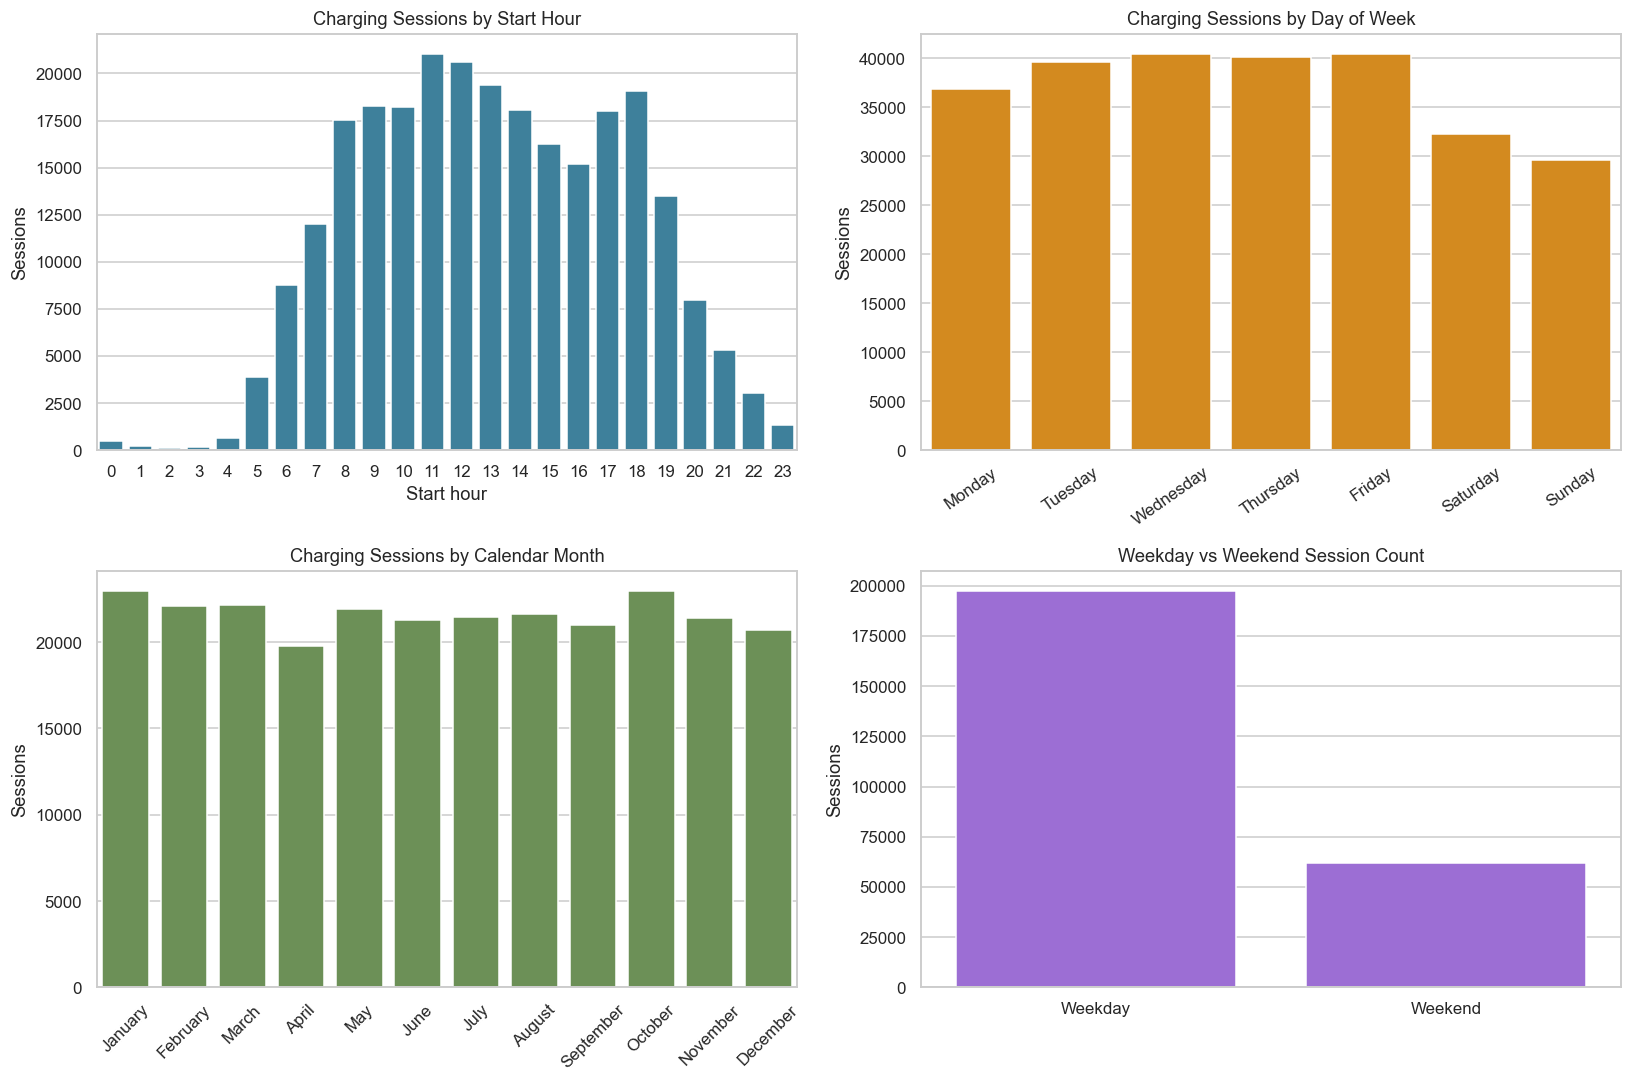

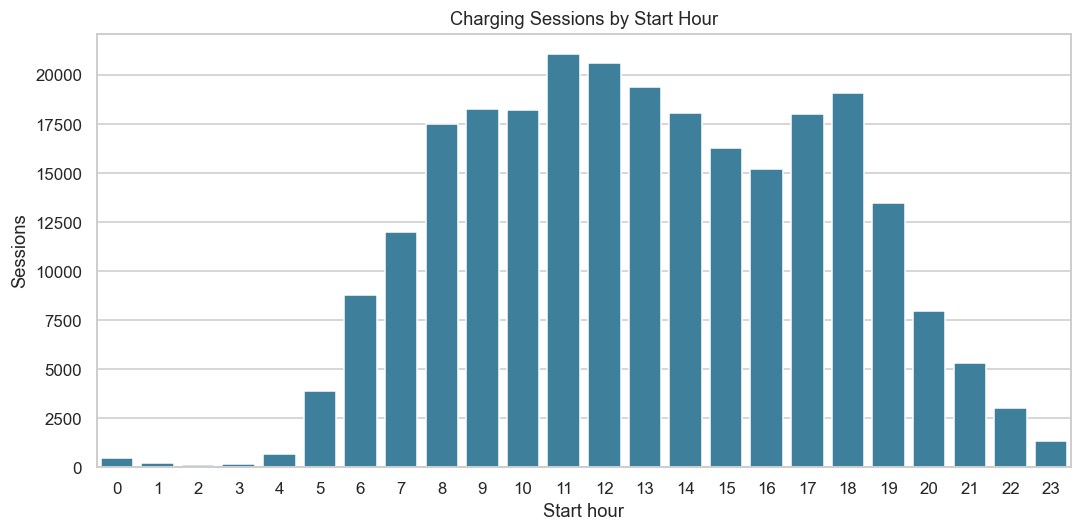

**Findings.** The busiest start hour is **11:00**, the busiest day is **Wednesday**, and the busiest calendar month is **January**. Weekdays account for **76.1%** of sessions. These are usage counts, not measures of unmet demand.

In [9]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
hourly_usage = df.groupby('hour_of_day').agg(sessions=('energy_kWh','size'), total_energy_kWh=('energy_kWh','sum'), average_energy_kWh=('energy_kWh','mean')).reset_index()
dow_usage = df.groupby('day_of_week').agg(sessions=('energy_kWh','size'), total_energy_kWh=('energy_kWh','sum'), average_energy_kWh=('energy_kWh','mean')).reindex(day_order).reset_index()
month_usage = df.groupby('month_name').agg(sessions=('energy_kWh','size'), total_energy_kWh=('energy_kWh','sum'), average_energy_kWh=('energy_kWh','mean')).reindex(month_order).reset_index()
year_usage = df.groupby('year').agg(sessions=('energy_kWh','size'), total_energy_kWh=('energy_kWh','sum')).reset_index()
daytype_usage = df.groupby('day_type').agg(sessions=('energy_kWh','size'), total_energy_kWh=('energy_kWh','sum'), average_energy_kWh=('energy_kWh','mean')).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
sns.barplot(data=hourly_usage, x='hour_of_day', y='sessions', color='#2E86AB', ax=axes[0,0]); axes[0,0].set(title='Charging Sessions by Start Hour', xlabel='Start hour', ylabel='Sessions')
sns.barplot(data=dow_usage, x='day_of_week', y='sessions', color='#F18F01', ax=axes[0,1]); axes[0,1].tick_params(axis='x', rotation=35); axes[0,1].set(title='Charging Sessions by Day of Week', xlabel='', ylabel='Sessions')
sns.barplot(data=month_usage, x='month_name', y='sessions', color='#6A994E', ax=axes[1,0]); axes[1,0].tick_params(axis='x', rotation=45); axes[1,0].set(title='Charging Sessions by Calendar Month', xlabel='', ylabel='Sessions')
sns.barplot(data=daytype_usage, x='day_type', y='sessions', color='#9B5DE5', ax=axes[1,1]); axes[1,1].set(title='Weekday vs Weekend Session Count', xlabel='', ylabel='Sessions')
plt.tight_layout(); plt.savefig(FIGURE_DIR/'charging_sessions_by_time.png', bbox_inches='tight'); plt.show()

plt.figure(figsize=(10,5)); sns.barplot(data=hourly_usage, x='hour_of_day', y='sessions', color='#2E86AB'); plt.title('Charging Sessions by Start Hour'); plt.xlabel('Start hour'); plt.ylabel('Sessions'); plt.tight_layout(); plt.savefig(FIGURE_DIR/'charging_sessions_by_hour.png', bbox_inches='tight'); plt.show()

busiest_hour = int(hourly_usage.loc[hourly_usage.sessions.idxmax(), 'hour_of_day'])
busiest_day = dow_usage.loc[dow_usage.sessions.idxmax(), 'day_of_week']
busiest_month = month_usage.loc[month_usage.sessions.idxmax(), 'month_name']
weekday_share = (~df['weekend']).mean()*100
display(Markdown(f'''**Findings.** The busiest start hour is **{busiest_hour}:00**, the busiest day is **{busiest_day}**, and the busiest calendar month is **{busiest_month}**. Weekdays account for **{weekday_share:.1f}%** of sessions. These are usage counts, not measures of unmet demand.'''))

## 6. Research Question 2: How has charging usage changed over time?

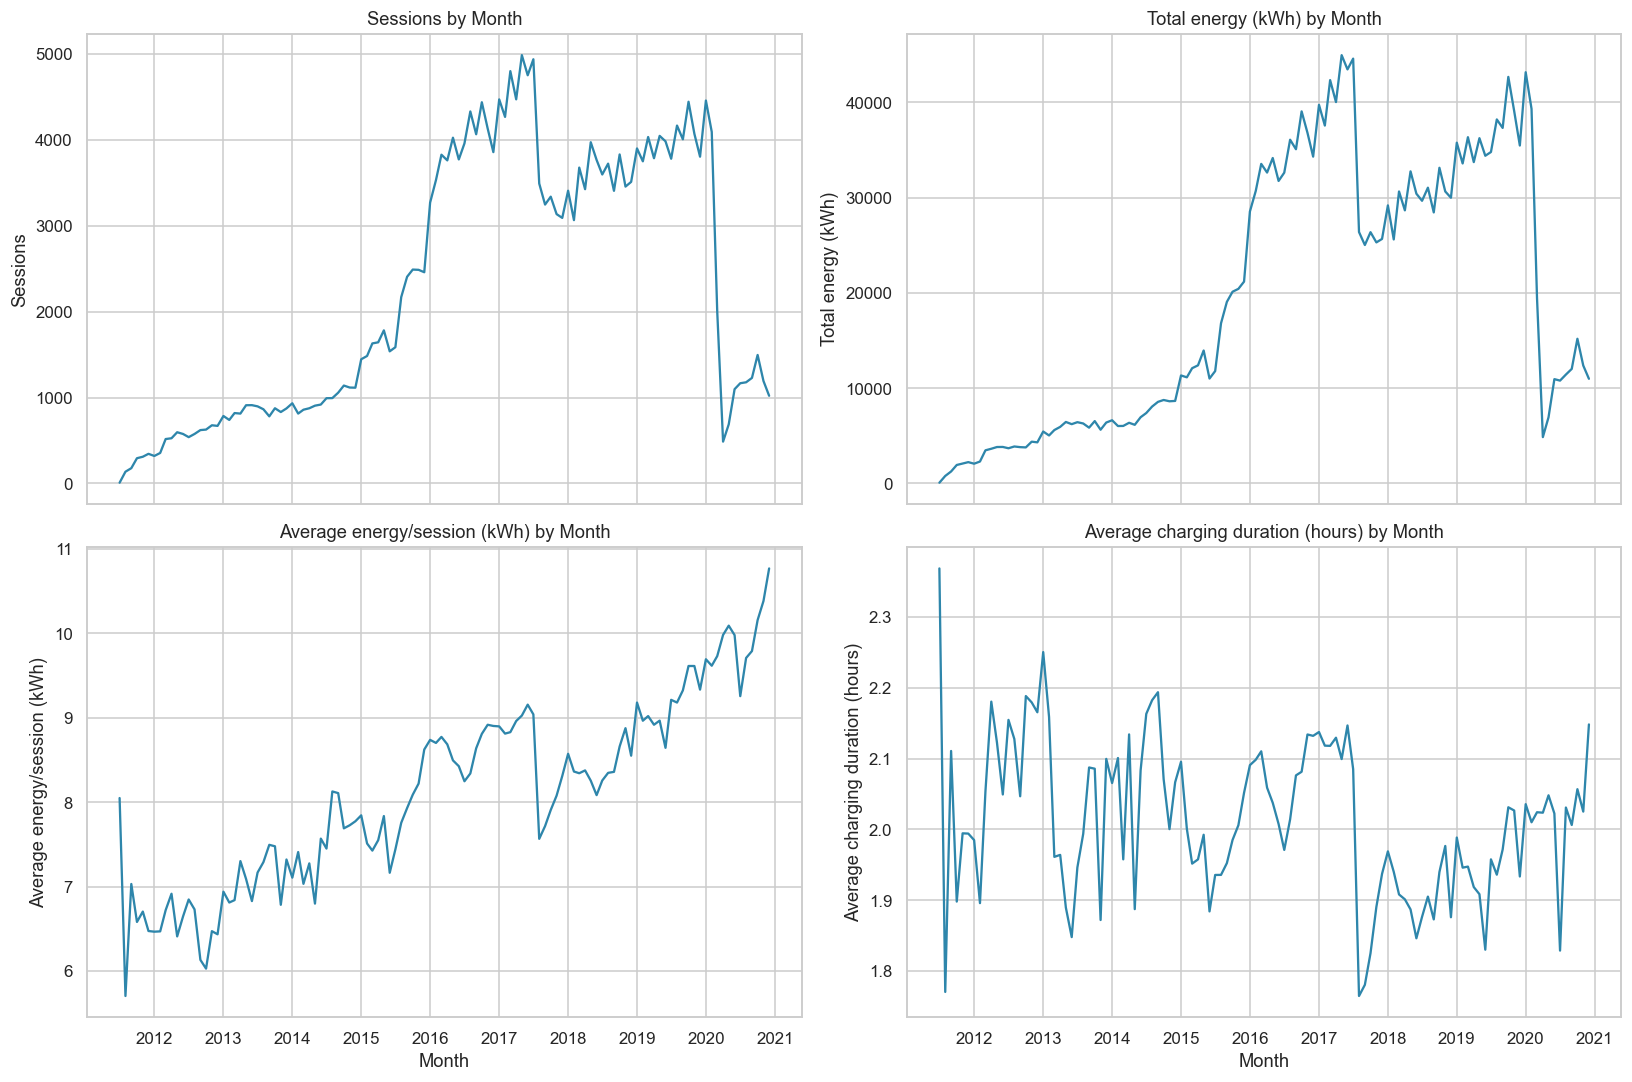

Months represented in partial years:


,months_present
year,
2011,6


,year,sessions,total_energy_kWh,average_energy_kWh,average_charging_hours
0,2011,1274,"8,357.610",6.560,1.967
1,2012,6600,"42,968.755",6.510,2.109
2,2013,10097,"71,830.570",7.114,2.008
3,2014,11712,"88,210.686",7.532,2.077
4,2015,23104,"181,334.805",7.849,1.980
5,2016,46930,"405,344.918",8.637,2.067
6,2017,48950,"421,516.917",8.611,2.025
7,2018,42803,"360,270.736",8.417,1.907
8,2019,47731,"437,690.279",9.170,1.950
9,2020,20094,"197,503.787",9.829,2.021


The first and/or last calendar year should not be compared as a full year when fewer than 12 months are represented. Trends are descriptive and do not establish causes such as adoption, station additions, policy, or the pandemic.

In [10]:
monthly_usage = df.groupby('year_month').agg(
    sessions=('energy_kWh','size'), total_energy_kWh=('energy_kWh','sum'),
    average_energy_kWh=('energy_kWh','mean'), average_charging_hours=('charging_duration_hours','mean')
).reset_index()
monthly_usage['date'] = pd.to_datetime(monthly_usage['year_month'])

fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
metrics = [('sessions','Sessions'),('total_energy_kWh','Total energy (kWh)'),('average_energy_kWh','Average energy/session (kWh)'),('average_charging_hours','Average charging duration (hours)')]
for ax, (col, label) in zip(axes.flat, metrics):
    sns.lineplot(data=monthly_usage, x='date', y=col, ax=ax, color='#2E86AB')
    ax.set(title=label+' by Month', xlabel='Month', ylabel=label)
plt.tight_layout(); plt.savefig(FIGURE_DIR/'monthly_charging_trend.png', bbox_inches='tight'); plt.show()

coverage = df.groupby('year')['month'].nunique()
partial_years = coverage[coverage < 12]
print('Months represented in partial years:')
display(partial_years.to_frame('months_present'))
annual = df.groupby('year').agg(sessions=('energy_kWh','size'), total_energy_kWh=('energy_kWh','sum'), average_energy_kWh=('energy_kWh','mean'), average_charging_hours=('charging_duration_hours','mean')).reset_index()
display(annual)
display(Markdown('The first and/or last calendar year should not be compared as a full year when fewer than 12 months are represented. Trends are descriptive and do not establish causes such as adoption, station additions, policy, or the pandemic.'))

## 7. Research Question 3: Relationship between charging duration and energy

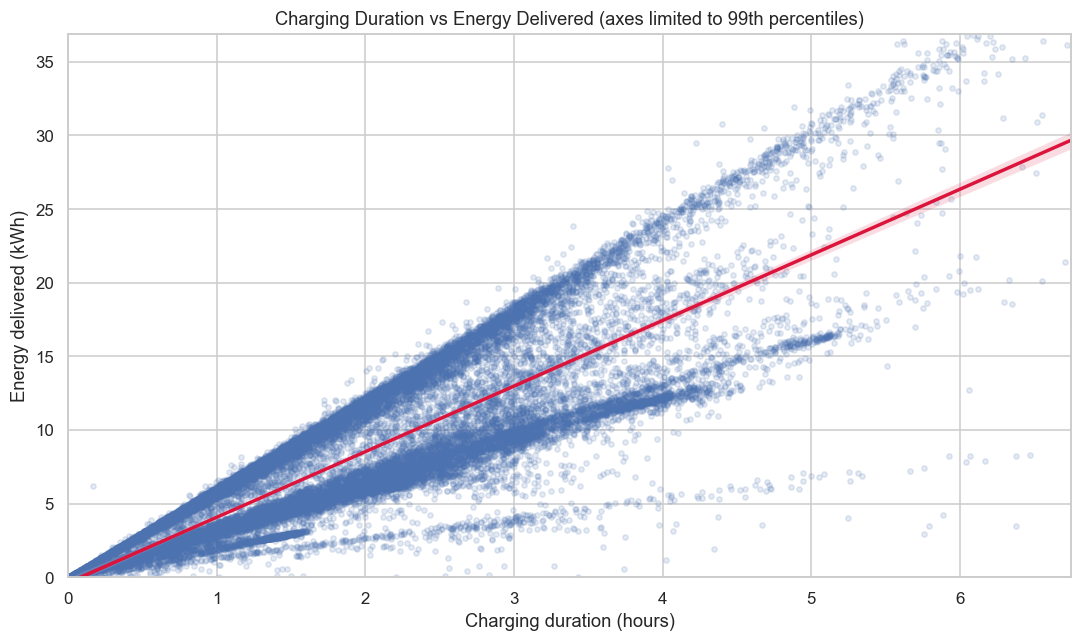

Pearson correlation: r=0.871, p=0
Among the longest 1% of charging sessions, energy ranges from 0.03 to 97.36 kWh.


Charging duration and energy have a Pearson correlation of **0.871**. Extremely long sessions do not all deliver the same or necessarily extreme energy. Correlation measures linear association; it does not prove that duration alone causes energy use because vehicle limits, charging level, state of charge, interruptions, and station characteristics may also matter.

In [11]:
pearson_r, pearson_p = stats.pearsonr(df['charging_duration_hours'], df['energy_kWh'])
sample_plot = df.sample(min(30000, len(df)), random_state=42)
plt.figure(figsize=(10,6))
sns.regplot(data=sample_plot, x='charging_duration_hours', y='energy_kWh', scatter_kws={'alpha':.15,'s':12}, line_kws={'color':'crimson'}, lowess=False)
plt.xlim(0, df['charging_duration_hours'].quantile(.99)); plt.ylim(0, df['energy_kWh'].quantile(.99))
plt.title('Charging Duration vs Energy Delivered (axes limited to 99th percentiles)'); plt.xlabel('Charging duration (hours)'); plt.ylabel('Energy delivered (kWh)')
plt.tight_layout(); plt.savefig(FIGURE_DIR/'duration_vs_energy.png', bbox_inches='tight'); plt.show()

long_cut = df['charging_duration_hours'].quantile(.99)
long_sessions = df[df['charging_duration_hours'] >= long_cut]
print(f'Pearson correlation: r={pearson_r:.3f}, p={pearson_p:.3g}')
print(f'Among the longest 1% of charging sessions, energy ranges from {long_sessions.energy_kWh.min():.2f} to {long_sessions.energy_kWh.max():.2f} kWh.')
display(Markdown(f'''Charging duration and energy have a Pearson correlation of **{pearson_r:.3f}**. Extremely long sessions do not all deliver the same or necessarily extreme energy. Correlation measures linear association; it does not prove that duration alone causes energy use because vehicle limits, charging level, state of charge, interruptions, and station characteristics may also matter.'''))

## 8. Research Question 4: How do stations/locations differ?

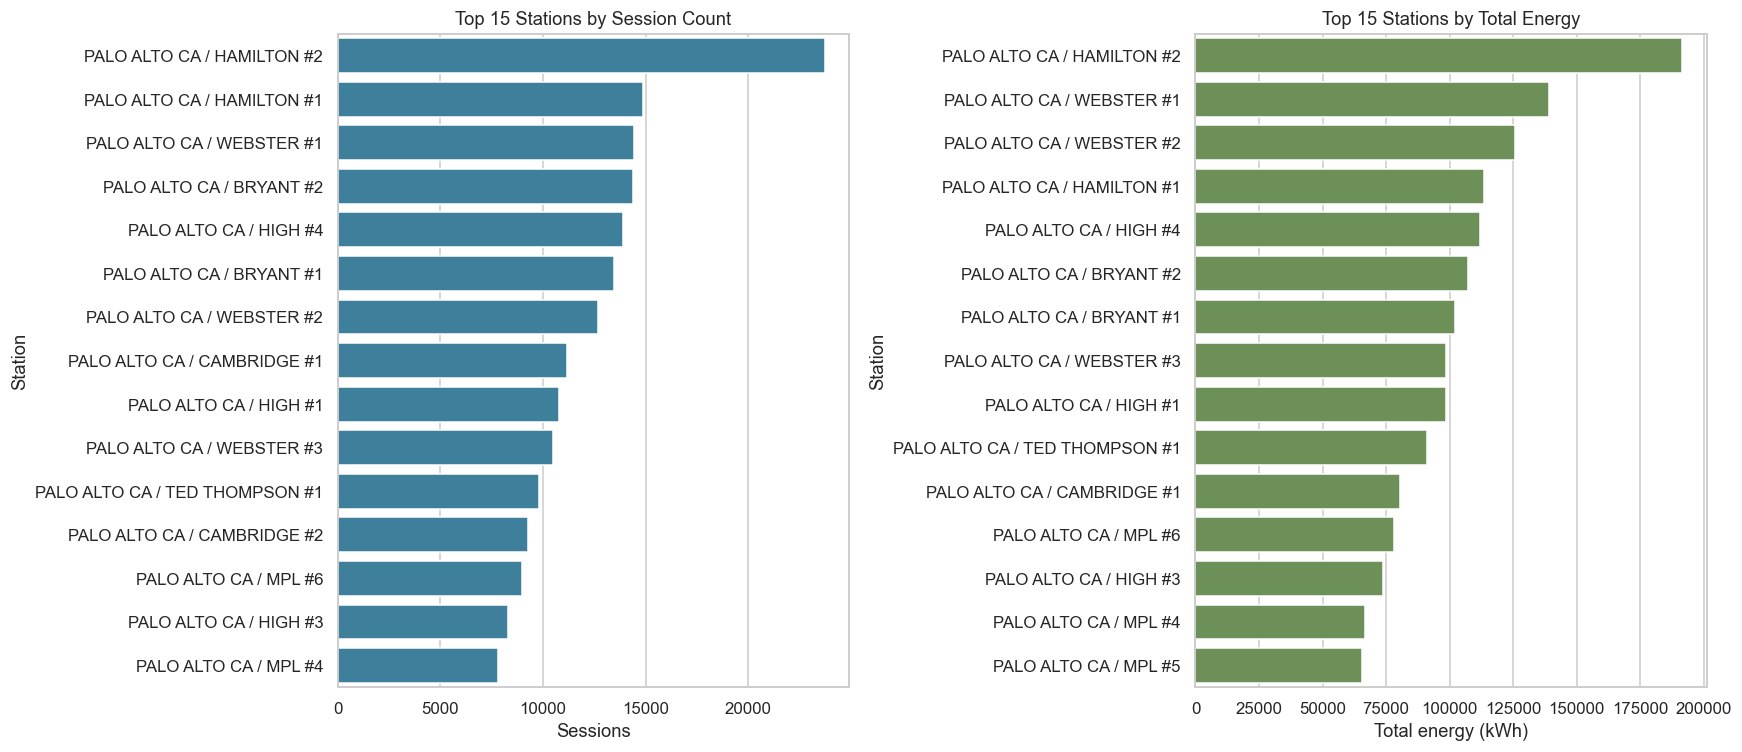

,Station Name,sessions,total_energy_kWh,average_energy_kWh,average_charging_hours,median_charging_hours,average_connection_hours,average_idle_hours
0,PALO ALTO CA / HAMILTON #2,23706,"191,525.399",8.079,2.033,1.847,2.517,0.484
1,PALO ALTO CA / HAMILTON #1,14879,"113,655.509",7.639,2.043,1.837,2.525,0.482
2,PALO ALTO CA / WEBSTER #1,14424,"139,007.648",9.637,2.146,2.043,2.763,0.616
3,PALO ALTO CA / BRYANT #2,14379,"107,193.927",7.455,2.002,1.792,2.548,0.546
4,PALO ALTO CA / HIGH #4,13893,"111,845.355",8.050,1.947,1.861,2.363,0.416
5,PALO ALTO CA / BRYANT #1,13432,"102,218.464",7.610,2.072,1.843,2.603,0.531
6,PALO ALTO CA / WEBSTER #2,12665,"125,697.977",9.925,2.164,2.029,2.811,0.647
7,PALO ALTO CA / CAMBRIDGE #1,11159,"80,492.339",7.213,1.878,1.659,2.279,0.401
8,PALO ALTO CA / HIGH #1,10751,"98,361.414",9.149,1.928,1.790,2.382,0.454
9,PALO ALTO CA / WEBSTER #3,10476,"98,508.374",9.403,2.091,2.000,2.664,0.572


In [12]:
if COL['station']:
    station_summary = df.groupby(COL['station']).agg(
        sessions=('energy_kWh','size'), total_energy_kWh=('energy_kWh','sum'),
        average_energy_kWh=('energy_kWh','mean'), average_charging_hours=('charging_duration_hours','mean'),
        median_charging_hours=('charging_duration_hours','median'), average_connection_hours=('connection_duration_hours','mean'),
        average_idle_hours=('idle_time_hours','mean')
    ).sort_values('sessions', ascending=False).reset_index()
    top = station_summary.head(15)
    fig, axes = plt.subplots(1,2,figsize=(16,7))
    sns.barplot(data=top, y=COL['station'], x='sessions', color='#2E86AB', ax=axes[0]); axes[0].set(title='Top 15 Stations by Session Count', xlabel='Sessions', ylabel='Station')
    energy_top = station_summary.nlargest(15,'total_energy_kWh')
    sns.barplot(data=energy_top, y=COL['station'], x='total_energy_kWh', color='#6A994E', ax=axes[1]); axes[1].set(title='Top 15 Stations by Total Energy', xlabel='Total energy (kWh)', ylabel='Station')
    plt.tight_layout(); plt.savefig(FIGURE_DIR/'top_charging_stations.png', bbox_inches='tight'); plt.show()
    display(station_summary.head(15))
else:
    station_summary = pd.DataFrame()
    print('Station/location field unavailable; this section is skipped.')

## 9. Research Question 5: Weekday vs weekend charging

,day_type,sessions,total_energy_kWh,average_energy_kWh,median_energy_kWh,average_charging_hours,median_charging_hours,average_start_hour
0,Weekday,197431,"1,717,568.758",8.700,7.094,2.070,1.954,12.939
1,Weekend,61864,"497,460.304",8.041,6.044,1.771,1.426,13.572


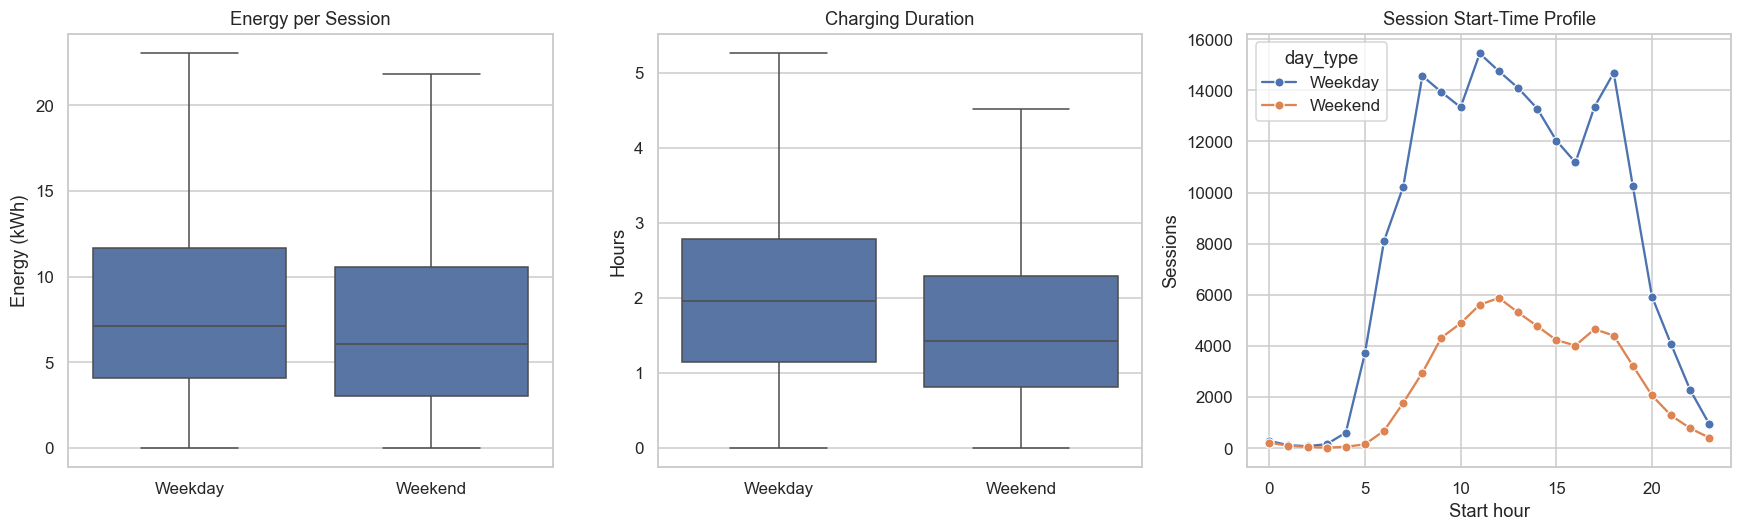

Weekend sessions use **-7.6%** average energy and have **-14.5%** average charging duration relative to weekday sessions. The table and plots show whether these differences are modest or substantial in practical terms; the comparison is unadjusted for station mix or year.

In [13]:
weekday_weekend = df.groupby('day_type').agg(
    sessions=('energy_kWh','size'), total_energy_kWh=('energy_kWh','sum'),
    average_energy_kWh=('energy_kWh','mean'), median_energy_kWh=('energy_kWh','median'),
    average_charging_hours=('charging_duration_hours','mean'), median_charging_hours=('charging_duration_hours','median'),
    average_start_hour=('hour_of_day','mean')
).reset_index()
display(weekday_weekend)
fig, axes = plt.subplots(1,3,figsize=(16,5))
sns.boxplot(data=df, x='day_type', y='energy_kWh', showfliers=False, ax=axes[0]); axes[0].set(title='Energy per Session', xlabel='', ylabel='Energy (kWh)')
sns.boxplot(data=df, x='day_type', y='charging_duration_hours', showfliers=False, ax=axes[1]); axes[1].set(title='Charging Duration', xlabel='', ylabel='Hours')
start_profile = df.groupby(['day_type','hour_of_day']).size().rename('sessions').reset_index()
sns.lineplot(data=start_profile, x='hour_of_day', y='sessions', hue='day_type', marker='o', ax=axes[2]); axes[2].set(title='Session Start-Time Profile', xlabel='Start hour', ylabel='Sessions')
plt.tight_layout(); plt.savefig(FIGURE_DIR/'weekday_weekend_comparison.png', bbox_inches='tight'); plt.show()

ww = weekday_weekend.set_index('day_type')
energy_diff = (ww.loc['Weekend','average_energy_kWh']/ww.loc['Weekday','average_energy_kWh']-1)*100
duration_diff = (ww.loc['Weekend','average_charging_hours']/ww.loc['Weekday','average_charging_hours']-1)*100
display(Markdown(f'''Weekend sessions use **{energy_diff:+.1f}%** average energy and have **{duration_diff:+.1f}%** average charging duration relative to weekday sessions. The table and plots show whether these differences are modest or substantial in practical terms; the comparison is unadjusted for station mix or year.'''))

## 10. Research Question 6: Seasonal charging patterns

,season,sessions,total_energy_kWh,average_energy_kWh,average_charging_hours
0,Winter,65786,"572,426.012",8.701,2.033
1,Spring,63819,"543,311.479",8.513,2.006
2,Summer,64361,"539,866.558",8.388,1.963
3,Fall,65329,"559,425.012",8.563,1.993


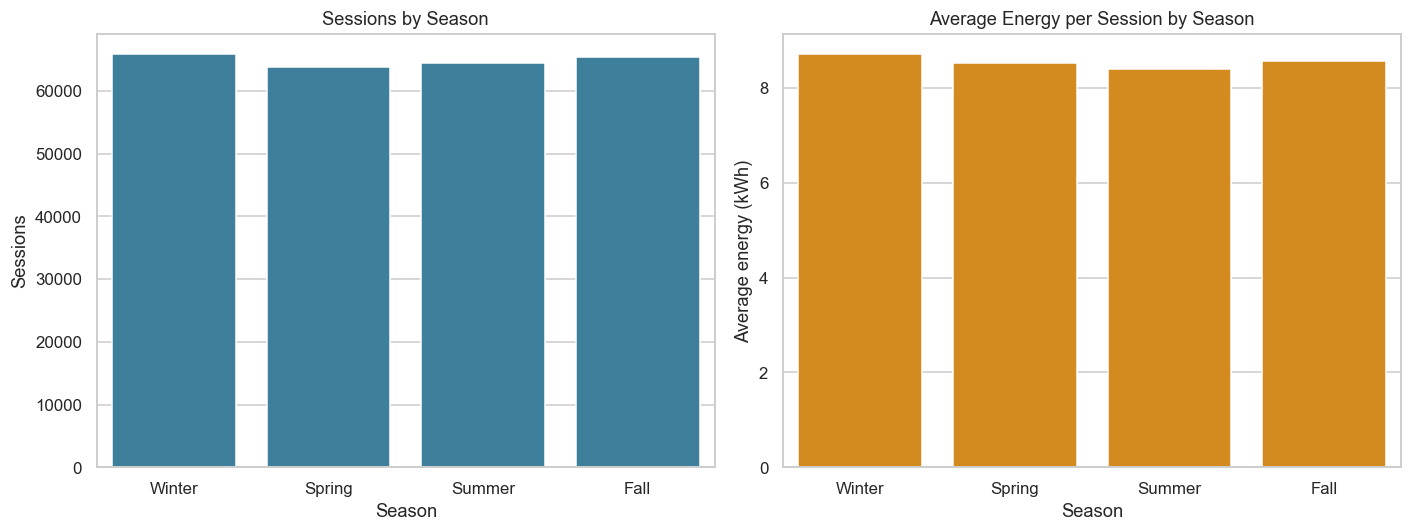

Seasonal totals combine multiple years and are influenced by unequal station availability and partial-year coverage. Differences describe the observed data and should not automatically be attributed to weather.

In [14]:
season_order = ['Winter','Spring','Summer','Fall']
seasonal = df.groupby('season').agg(sessions=('energy_kWh','size'), total_energy_kWh=('energy_kWh','sum'), average_energy_kWh=('energy_kWh','mean'), average_charging_hours=('charging_duration_hours','mean')).reindex(season_order).reset_index()
display(seasonal)
fig, axes = plt.subplots(1,2,figsize=(13,5))
sns.barplot(data=seasonal, x='season', y='sessions', color='#2E86AB', ax=axes[0]); axes[0].set(title='Sessions by Season', xlabel='Season', ylabel='Sessions')
sns.barplot(data=seasonal, x='season', y='average_energy_kWh', color='#F18F01', ax=axes[1]); axes[1].set(title='Average Energy per Session by Season', xlabel='Season', ylabel='Average energy (kWh)')
plt.tight_layout(); plt.savefig(FIGURE_DIR/'seasonal_charging_patterns.png', bbox_inches='tight'); plt.show()
display(Markdown('Seasonal totals combine multiple years and are influenced by unequal station availability and partial-year coverage. Differences describe the observed data and should not automatically be attributed to weather.'))

## 11. Research Question 7: Charger occupancy and idle behavior

,idle_time_hours
count,"259,295.000"
mean,0.488
std,1.479
min,0.000
50%,0.007
75%,0.355
90%,1.222
95%,2.312
99%,7.765
max,112.547


Sessions with at least 1 hour of idle time: 12.1%


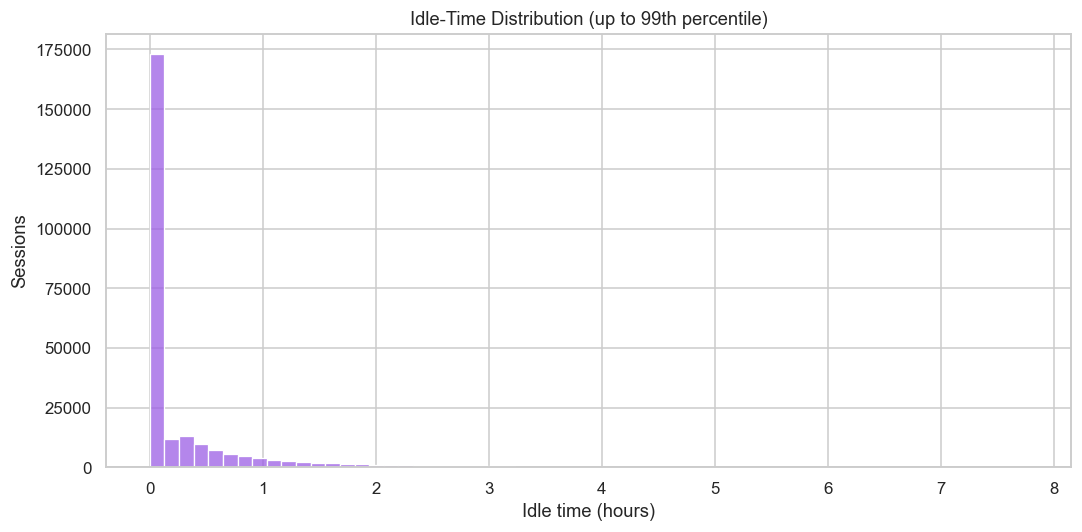

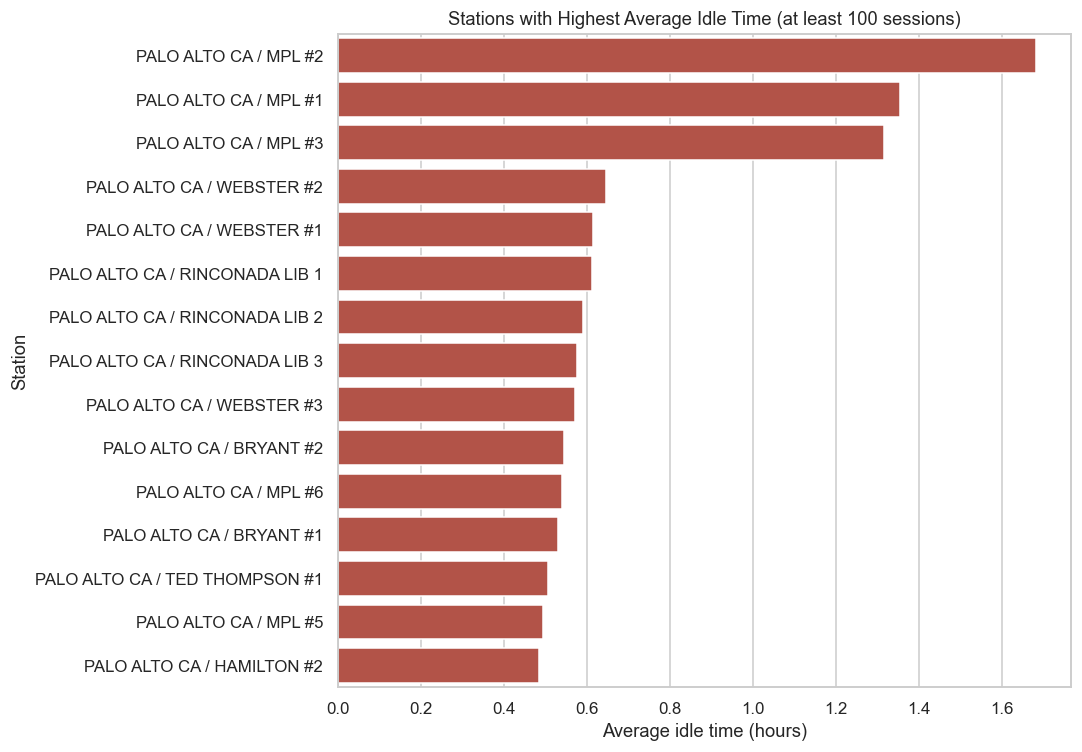

Here, “substantial idle time” means **at least 1 hour** connected after active charging. This is an analytical threshold, not an official operating standard. The results indicate how often vehicles may remain connected after charging, but do not show whether parking rules permitted it.

In [15]:
substantial_idle_threshold = 1.0  # analytical definition, not an official standard
idle_stats = df['idle_time_hours'].describe(percentiles=[.5,.75,.9,.95,.99])
substantial_idle_pct = (df['idle_time_hours'] >= substantial_idle_threshold).mean()*100
display(idle_stats.to_frame('idle_time_hours'))
print(f'Sessions with at least {substantial_idle_threshold:.0f} hour of idle time: {substantial_idle_pct:.1f}%')
plt.figure(figsize=(10,5)); sns.histplot(df.loc[df.idle_time_hours <= df.idle_time_hours.quantile(.99),'idle_time_hours'], bins=60, color='#9B5DE5'); plt.title('Idle-Time Distribution (up to 99th percentile)'); plt.xlabel('Idle time (hours)'); plt.ylabel('Sessions'); plt.tight_layout(); plt.savefig(FIGURE_DIR/'idle_time_distribution.png', bbox_inches='tight'); plt.show()
if COL['station']:
    idle_station = df.groupby(COL['station']).agg(average_idle_hours=('idle_time_hours','mean'), sessions=('idle_time_hours','size')).query('sessions >= 100').nlargest(15,'average_idle_hours').reset_index()
    plt.figure(figsize=(10,7)); sns.barplot(data=idle_station, y=COL['station'], x='average_idle_hours', color='#C44536'); plt.title('Stations with Highest Average Idle Time (at least 100 sessions)'); plt.xlabel('Average idle time (hours)'); plt.ylabel('Station'); plt.tight_layout(); plt.savefig(FIGURE_DIR/'stations_highest_idle_time.png', bbox_inches='tight'); plt.show()
display(Markdown(f'''Here, “substantial idle time” means **at least {substantial_idle_threshold:.0f} hour** connected after active charging. This is an analytical threshold, not an official operating standard. The results indicate how often vehicles may remain connected after charging, but do not show whether parking rules permitted it.'''))

## 12. Outlier analysis

,variable,lower_fence,upper_fence,potential_outliers,percent
0,energy_kWh,-7.725,22.968,8683,3.349
1,charging_duration_hours,-1.446,5.183,5501,2.122
2,connection_duration_hours,-1.708,5.969,12758,4.920
3,idle_time_hours,-0.522,0.881,34965,13.485
4,energy_per_hour,-0.947,9.883,13,0.005


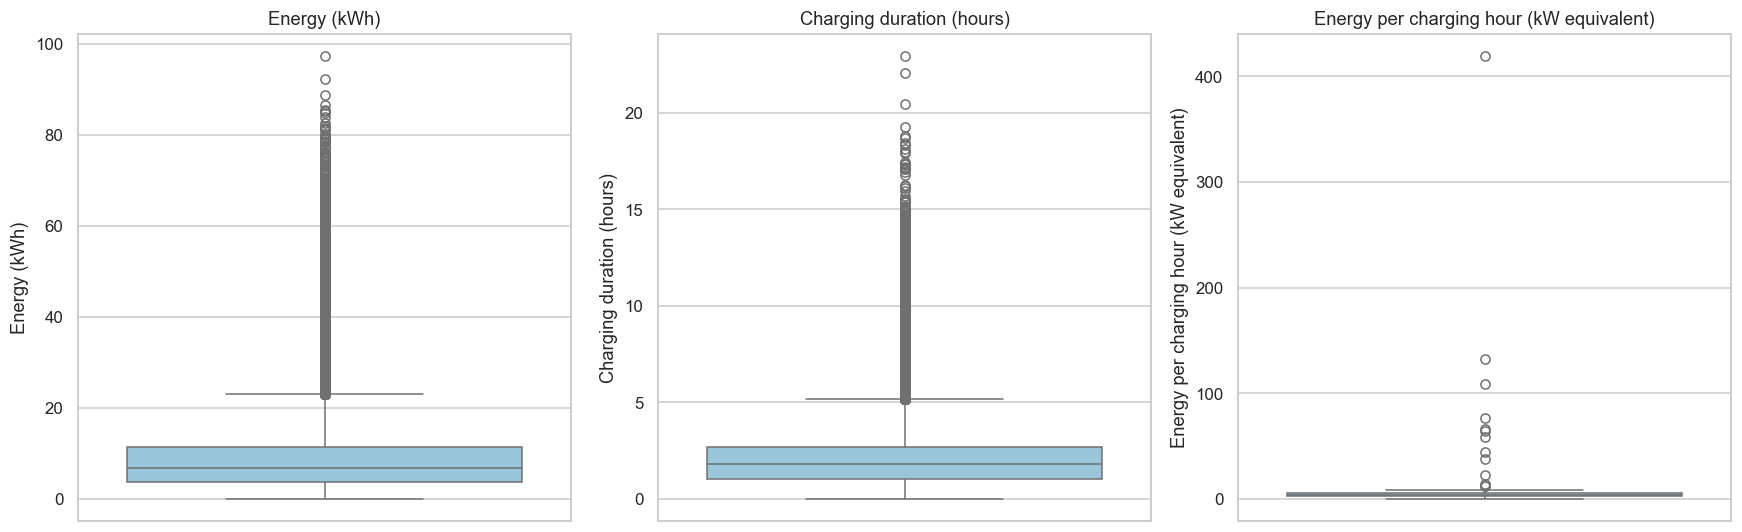

Very long connection + bottom-decile energy sessions: 18
99th percentile thresholds — energy: 36.90 kWh, connection: 12.00 h, charging rate: 6.21 kW equivalent


IQR flags are screening indicators, not proof of error. Unusual values may reflect overnight parking, interrupted charging, different charger power, data logging behavior, or legitimate high-capacity sessions. They remain in the cleaned dataset unless an objective validity rule is violated.

In [16]:
def iqr_flags(series):
    q1, q3 = series.quantile([.25,.75]); iqr = q3-q1
    return (series < q1-1.5*iqr) | (series > q3+1.5*iqr), q1-1.5*iqr, q3+1.5*iqr

outlier_rows = []
for col in ['energy_kWh','charging_duration_hours','connection_duration_hours','idle_time_hours','energy_per_hour']:
    flags, low, high = iqr_flags(df[col].dropna())
    outlier_rows.append({'variable':col,'lower_fence':low,'upper_fence':high,'potential_outliers':int(flags.sum()),'percent':flags.mean()*100})
outlier_summary = pd.DataFrame(outlier_rows)
display(outlier_summary)

fig, axes = plt.subplots(1,3,figsize=(16,5))
for ax, col, label in zip(axes,['energy_kWh','charging_duration_hours','energy_per_hour'],['Energy (kWh)','Charging duration (hours)','Energy per charging hour (kW equivalent)']):
    sns.boxplot(y=df[col], showfliers=True, ax=ax, color='#8ECAE6'); ax.set_title(label); ax.set_ylabel(label)
plt.tight_layout(); plt.savefig(FIGURE_DIR/'outlier_boxplots.png', bbox_inches='tight'); plt.show()

energy_p99 = df.energy_kWh.quantile(.99); connection_p99 = df.connection_duration_hours.quantile(.99); rate_p99 = df.energy_per_hour.quantile(.99)
suspicious_low_energy_long = df[(df.connection_duration_hours >= connection_p99) & (df.energy_kWh <= df.energy_kWh.quantile(.10))]
print(f'Very long connection + bottom-decile energy sessions: {len(suspicious_low_energy_long):,}')
print(f'99th percentile thresholds — energy: {energy_p99:.2f} kWh, connection: {connection_p99:.2f} h, charging rate: {rate_p99:.2f} kW equivalent')
display(Markdown('IQR flags are screening indicators, not proof of error. Unusual values may reflect overnight parking, interrupted charging, different charger power, data logging behavior, or legitimate high-capacity sessions. They remain in the cleaned dataset unless an objective validity rule is violated.'))

## 13. Correlation analysis

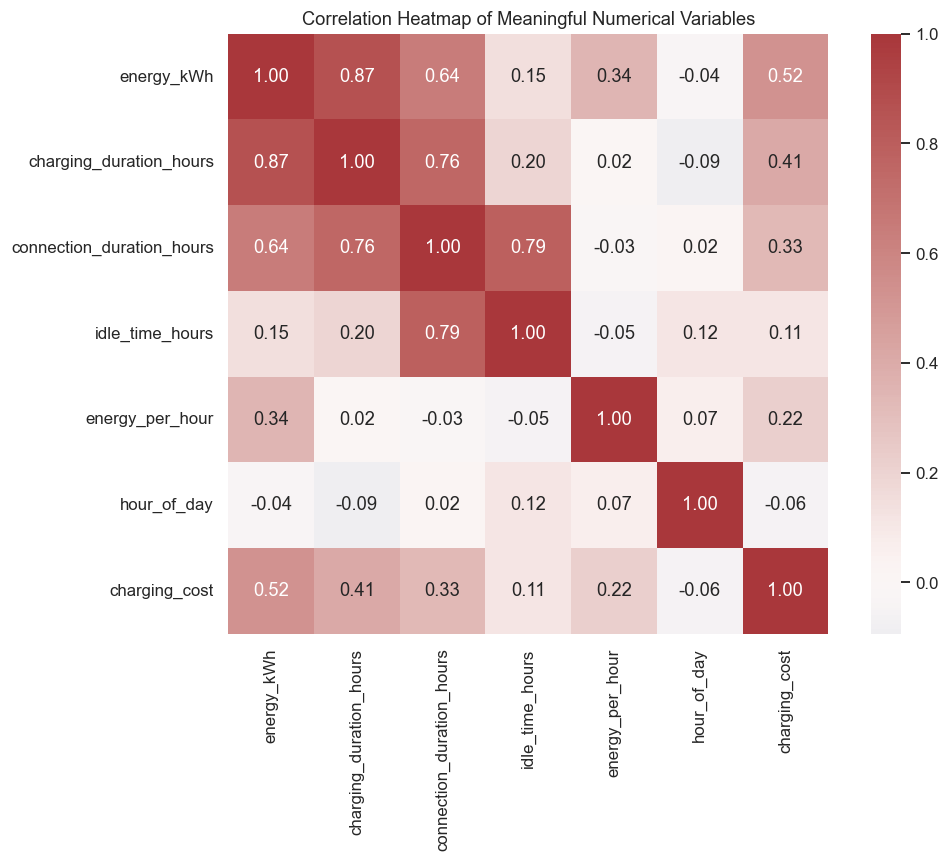

correlation
energy_kWh                charging_duration_hours          0.871
connection_duration_hours idle_time_hours                  0.791
charging_duration_hours   connection_duration_hours        0.755
energy_kWh                connection_duration_hours        0.643
                          charging_cost                    0.523
charging_duration_hours   charging_cost                    0.410
energy_kWh                energy_per_hour                  0.342
connection_duration_hours charging_cost                    0.332
energy_per_hour           charging_cost                    0.223
charging_duration_hours   idle_time_hours                  0.196

Identifiers such as EVSE ID, port number, user ID, and event ID are intentionally excluded. Correlation describes association, not causation.

In [17]:
numeric_cols = ['energy_kWh','charging_duration_hours','connection_duration_hours','idle_time_hours','energy_per_hour','hour_of_day']
if 'charging_cost' in df: numeric_cols.append('charging_cost')
corr = df[numeric_cols].corr(numeric_only=True)
plt.figure(figsize=(10,8)); sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', center=0, square=True); plt.title('Correlation Heatmap of Meaningful Numerical Variables'); plt.tight_layout(); plt.savefig(FIGURE_DIR/'correlation_heatmap.png', bbox_inches='tight'); plt.show()
pairs = corr.where(np.triu(np.ones(corr.shape),1).astype(bool)).stack().sort_values(key=abs, ascending=False)
display(pairs.head(10).rename('correlation').to_frame())
display(Markdown('Identifiers such as EVSE ID, port number, user ID, and event ID are intentionally excluded. Correlation describes association, not causation.'))

## 14. Optional exploratory clustering

,k,inertia,silhouette
0,2,"137,874.219",0.363
1,3,"103,028.468",0.375
2,4,"70,544.274",0.413
3,5,"56,327.316",0.400


charging_duration_hours              energy_kWh                \
                          count  mean median      count   mean median   
cluster                                                                 
0                          1582 3.440  3.530       1582 14.405 12.494   
1                         22940 1.640  1.632      22940  4.905  4.892   
2                         10916 3.522  3.264      10916 17.120 15.353   
3                         14562 1.167  1.166      14562  6.703  6.694   

        idle_time_hours              energy_per_hour               
                  count  mean median           count  mean median  
cluster                                                            
0                  1582 6.201  6.452            1582 4.109  3.632  
1                 22940 0.317  0.010           22940 2.993  3.125  
2                 10916 0.314  0.008           10916 4.950  5.496  
3                 14562 0.166  0.005           14562 5.751  5.862

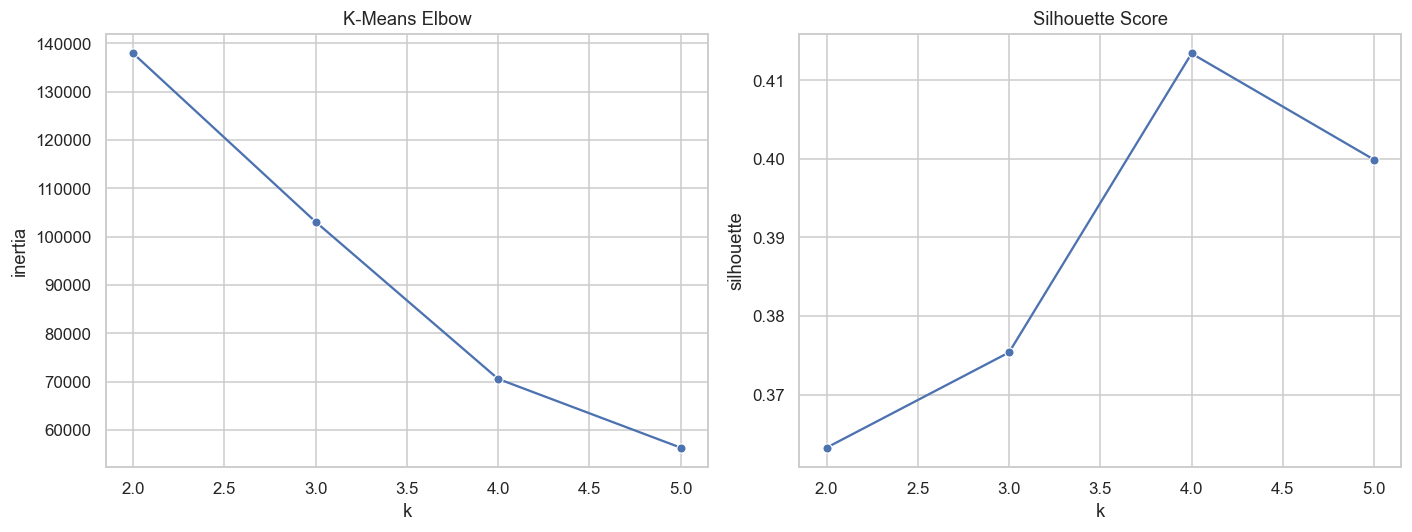

An exploratory **4-cluster** solution had the highest tested silhouette score. Groups are described only by their observed feature statistics; behavioral labels such as “commuter” are not assigned because the data do not establish user intent.

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

cluster_features = ['charging_duration_hours','energy_kWh','idle_time_hours','energy_per_hour']
cluster_data = df[cluster_features].replace([np.inf,-np.inf],np.nan).dropna()
# Winsorize for exploratory stability without changing the cleaned dataset.
cluster_x = cluster_data.copy()
for c in cluster_features:
    cluster_x[c] = cluster_x[c].clip(cluster_x[c].quantile(.01), cluster_x[c].quantile(.99))
cluster_x = cluster_x.sample(min(50000,len(cluster_x)), random_state=42)
X = StandardScaler().fit_transform(cluster_x)
cluster_scores=[]
for k in range(2,6):
    model=KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    sil=silhouette_score(X, model.labels_, sample_size=min(10000,len(X)), random_state=42)
    cluster_scores.append({'k':k,'inertia':model.inertia_,'silhouette':sil})
cluster_scores=pd.DataFrame(cluster_scores)
display(cluster_scores)
best_k=int(cluster_scores.loc[cluster_scores.silhouette.idxmax(),'k'])
final_model=KMeans(n_clusters=best_k, random_state=42, n_init=10).fit(X)
cluster_x=cluster_x.assign(cluster=final_model.labels_)
cluster_profile=cluster_x.groupby('cluster')[cluster_features].agg(['count','mean','median'])
display(cluster_profile)
fig, axes=plt.subplots(1,2,figsize=(13,5)); sns.lineplot(data=cluster_scores,x='k',y='inertia',marker='o',ax=axes[0]); axes[0].set_title('K-Means Elbow'); sns.lineplot(data=cluster_scores,x='k',y='silhouette',marker='o',ax=axes[1]); axes[1].set_title('Silhouette Score'); plt.tight_layout(); plt.savefig(FIGURE_DIR/'optional_clustering_diagnostics.png',bbox_inches='tight'); plt.show()
display(Markdown(f'An exploratory **{best_k}-cluster** solution had the highest tested silhouette score. Groups are described only by their observed feature statistics; behavioral labels such as “commuter” are not assigned because the data do not establish user intent.'))

## 15. Save cleaned and summary datasets

In [19]:
daily_usage = df.groupby('calendar_date').agg(sessions=('energy_kWh','size'), total_energy_kWh=('energy_kWh','sum'), average_energy_kWh=('energy_kWh','mean'), average_charging_hours=('charging_duration_hours','mean')).reset_index()
df.to_csv(OUTPUT_DIR/'cleaned_ev_charging_data.csv', index=False)
hourly_usage.to_csv(OUTPUT_DIR/'hourly_usage.csv', index=False)
daily_usage.to_csv(OUTPUT_DIR/'daily_usage.csv', index=False)
monthly_usage.to_csv(OUTPUT_DIR/'monthly_usage.csv', index=False)
station_summary.to_csv(OUTPUT_DIR/'station_summary.csv', index=False)
outlier_summary.to_csv(OUTPUT_DIR/'outlier_summary.csv', index=False)
print('Saved output CSV files:')
for p in sorted(OUTPUT_DIR.glob('*.csv')): print(' -', p.relative_to(ROOT))

Saved output CSV files:
 - outputs/cleaned_ev_charging_data.csv
 - outputs/daily_usage.csv
 - outputs/hourly_usage.csv
 - outputs/monthly_usage.csv
 - outputs/outlier_summary.csv
 - outputs/station_summary.csv


# Key Findings

In [20]:
peak_year = int(annual.loc[annual.sessions.idxmax(),'year'])
peak_year_sessions = int(annual.sessions.max())
top_station = station_summary.iloc[0][COL['station']] if not station_summary.empty else 'Unavailable'
top_station_sessions = int(station_summary.iloc[0].sessions) if not station_summary.empty else 0
peak_month_row = monthly_usage.loc[monthly_usage.sessions.idxmax()]
idle_mean = df.idle_time_hours.mean(); idle_median=df.idle_time_hours.median()
findings = [
    f'The cleaned dataset contains {len(df):,} sessions from {df.start_datetime.min():%B %d, %Y} to {df.start_datetime.max():%B %d, %Y}.',
    f'Sessions most often began at {busiest_hour}:00; {busiest_day} was the busiest day of week and {busiest_month} the busiest calendar month.',
    f'The data record {df.energy_kWh.sum():,.0f} kWh in total, averaging {df.energy_kWh.mean():.2f} kWh per session (median {df.energy_kWh.median():.2f} kWh).',
    f'Average active charging time was {df.charging_duration_hours.mean():.2f} hours; median charging time was {df.charging_duration_hours.median():.2f} hours.',
    f'Charging duration and energy delivered had a Pearson correlation of {pearson_r:.3f}.',
    f'Weekdays represented {weekday_share:.1f}% of all sessions.',
    f'Average idle time was {idle_mean:.2f} hours (median {idle_median:.2f}); {substantial_idle_pct:.1f}% of sessions had at least one hour of idle time.',
    f'The busiest observed year was {peak_year} with {peak_year_sessions:,} sessions; partial years must be interpreted cautiously.',
    f'The busiest individual month was {peak_month_row.year_month} with {int(peak_month_row.sessions):,} sessions.',
    f'The most-used station was {top_station}, with {top_station_sessions:,} sessions.' if COL['station'] else 'Station information was unavailable.'
]
display(Markdown('\n'.join(f'- {x}' for x in findings)))

- The cleaned dataset contains 259,295 sessions from July 29, 2011 to December 31, 2020.
- Sessions most often began at 11:00; Wednesday was the busiest day of week and January the busiest calendar month.
- The data record 2,215,029 kWh in total, averaging 8.54 kWh per session (median 6.87 kWh).
- Average active charging time was 2.00 hours; median charging time was 1.82 hours.
- Charging duration and energy delivered had a Pearson correlation of 0.871.
- Weekdays represented 76.1% of all sessions.
- Average idle time was 0.49 hours (median 0.01); 12.1% of sessions had at least one hour of idle time.
- The busiest observed year was 2017 with 48,950 sessions; partial years must be interpreted cautiously.
- The busiest individual month was 2017-05 with 4,982 sessions.
- The most-used station was PALO ALTO CA / HAMILTON #2, with 23,706 sessions.

# Limitations

- The data represent one city and one charging network context, so the results may not generalize elsewhere.
- This is observational session data. Associations cannot establish causal effects.
- Station inventory, pricing, equipment, and availability may have changed over time.
- The first calendar year is partial, and any other partial years are identified in the temporal section.
- Missing user, equipment, and location-detail fields limit some comparisons.
- Extreme observations may be legitimate or may reflect logging problems; they were retained unless objectively invalid.
- A recorded session does not measure unmet demand, queues, battery state of charge, trip purpose, or user intent.

# Conclusion

The dataset provides a long session-level view of public EV charging in Palo Alto. Usage is strongly structured by time of day, day type, year, station, and the distinction between active charging and total connection time. Energy increases with charging duration on average, but long occupancy does not guarantee high energy delivery. Station and idle-time differences show why session counts, energy, charging time, and connection time should be evaluated together.

## 16. Generate the executed project summary

In [21]:
figure_files = sorted(p.name for p in FIGURE_DIR.glob('*.png'))
partial_text = ', '.join(f'{int(y)} ({int(m)} months)' for y,m in partial_years.items()) or 'None'
results_md = f'''# Project Results: Exploratory Data Analysis of Electric Vehicle Charging Patterns

## 1. Dataset overview

- Source file: `{csv_path.name}`
- Original shape: **{df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns**
- Original date coverage: **{df.start_datetime.min():%B %d, %Y} to {df.start_datetime.max():%B %d, %Y}**
- Unique stations: **{int(station_count):,}**
- Public dataset reference: City of Palo Alto, Electric Vehicle Charging Station Usage (July 2011–December 2020).

## 2. Cleaning performed

- Removed exact duplicates and sessions with objectively invalid timestamps, negative energy, non-positive durations, or active charging time materially longer than total connection time.
- Retained missing descriptive fields when the session remained analytically usable.
- Retained statistically extreme but internally valid sessions for outlier analysis.
- Original records: **{original_rows:,}**
- Records removed: **{removed_rows:,}**
- Final records: **{len(df):,}**

## 3. Important descriptive statistics

- Total energy: **{df.energy_kWh.sum():,.2f} kWh**
- Average energy/session: **{df.energy_kWh.mean():.2f} kWh**
- Median energy/session: **{df.energy_kWh.median():.2f} kWh**
- Average charging duration: **{df.charging_duration_hours.mean():.2f} hours**
- Median charging duration: **{df.charging_duration_hours.median():.2f} hours**
- Average energy per charging hour: **{df.energy_per_hour.mean():.2f} kW equivalent**

## 4. Answers to the research questions

1. **When are chargers used most?** The busiest start hour was **{busiest_hour}:00**, the busiest day was **{busiest_day}**, and the busiest calendar month was **{busiest_month}**. Weekdays accounted for **{weekday_share:.1f}%** of sessions.
2. **How has usage changed over time?** The busiest observed year was **{peak_year}** with **{peak_year_sessions:,} sessions**. The busiest individual month was **{peak_month_row.year_month}** with **{int(peak_month_row.sessions):,} sessions**. Partial years: **{partial_text}**.
3. **Duration and energy:** Pearson correlation was **r = {pearson_r:.3f}** (p = {pearson_p:.3g}). Long sessions varied widely in energy, so duration is informative but not sufficient by itself.
4. **Station differences:** The busiest station was **{top_station}** with **{top_station_sessions:,} sessions**. Station summaries show differences in session count, energy, duration, and idle time.
5. **Weekday vs weekend:** Weekend sessions used **{energy_diff:+.1f}%** average energy and had **{duration_diff:+.1f}%** average charging time relative to weekdays.
6. **Seasonality:** **{seasonal.loc[seasonal.sessions.idxmax(),'season']}** had the most sessions, while **{seasonal.loc[seasonal.average_energy_kWh.idxmax(),'season']}** had the highest average energy per session. Totals are affected by multi-year growth and unequal coverage.
7. **Occupancy and idle behavior:** Average idle time was **{idle_mean:.2f} hours**, median idle time was **{idle_median:.2f} hours**, and **{substantial_idle_pct:.1f}%** of sessions had at least one hour of idle time (an analytical threshold, not an official standard).

## 5. Important relationships discovered

- Charging duration and energy had a positive linear association (**r = {pearson_r:.3f}**), but extreme duration did not guarantee extreme energy.
- Connection duration reflects both active charging and idle occupancy; these measures should not be used interchangeably.
- The correlation heatmap excludes numeric identifiers because their magnitude has no continuous analytical meaning.

## 6. Interesting or unexpected findings

''' + '\n'.join(f'- {x}' for x in findings[1:]) + f'''

## 7. Limitations

- One geographic area and charging-network context.
- Observational data cannot establish causation.
- Station inventory and policies may have changed over time.
- Partial calendar years: {partial_text}.
- Missing descriptive fields and possible logging anomalies.
- Outliers may be legitimate or erroneous; valid extremes were retained.
- No direct measures of queues, unmet demand, trip purpose, or battery state of charge.

## 8. Final conclusion

Palo Alto charging behavior varies materially by time, station, and day type. Energy and active charging duration move together, while connection time also contains meaningful post-charging idle occupancy. The results support evaluating session volume, energy, charging duration, and idle time together, without inferring causes from correlations alone.

## 9. Generated figures

''' + '\n'.join(f'- `figures/{name}`' for name in figure_files) + '\n'
(ROOT/'PROJECT_RESULTS.md').write_text(results_md, encoding='utf-8')
print(f'Created PROJECT_RESULTS.md with {len(figure_files)} figure references.')

Created PROJECT_RESULTS.md with 12 figure references.
